In [5]:
library(mclust)
library(tidyverse)

In [3]:
source("../R/shared_data.R")
df <- load_analysis_data()

In [4]:
var_quanti <- names(df)[sapply(df, is.numeric)]
df <- df %>%
  select(all_of(var_quanti))

Best BIC values:
            EEE,1    EEV,1    EVE,1
BIC      640133.2 640133.2 640133.2
BIC diff      0.0      0.0      0.0

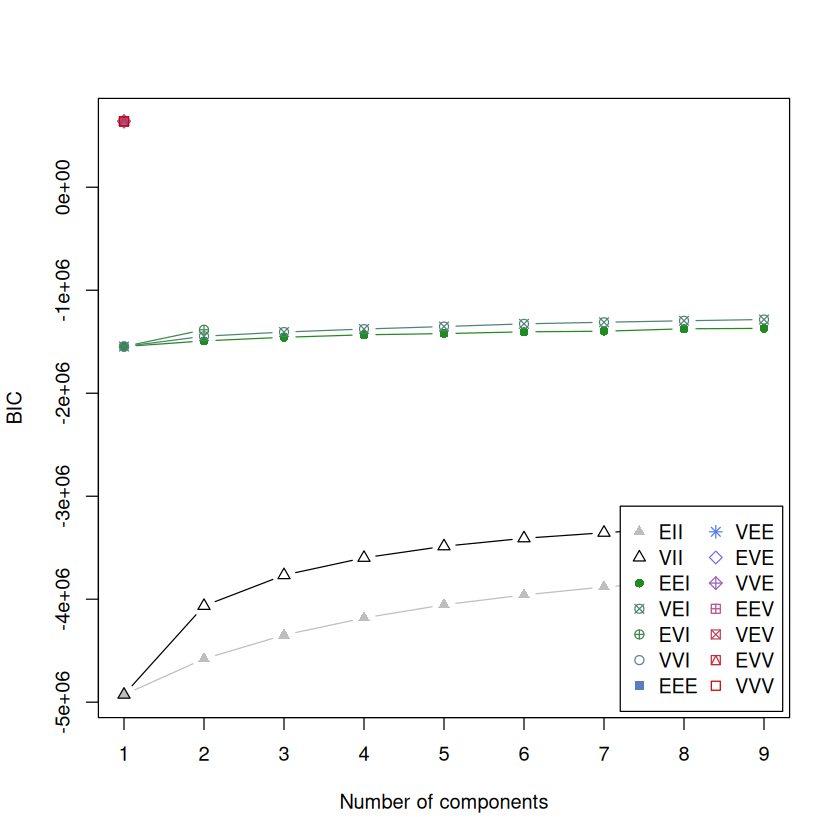

In [7]:
# mclust teste automatiquement K=1..9 et plusieurs structures de covariance
bic_model <- mclustBIC(df)
plot(bic_model)  # Visualiser le BIC → pic = meilleur K
summary(bic_model)

In [8]:
gmm_model <- Mclust(df, G = 3)  # ou laisser G=NULL pour auto-sélection
summary(gmm_model, parameters = TRUE)

---------------------------------------------------- 
Gaussian finite mixture model fitted by EM algorithm 
---------------------------------------------------- 

Mclust EVI (diagonal, equal volume, varying shape) model with 3 components: 

 log-likelihood     n  df      BIC      ICL
      -652617.4 14252 144 -1306612 -1307214

Clustering table:
   1    2    3 
3769 8415 2068 

Mixing probabilities:
        1         2         3 
0.2671564 0.5869673 0.1458763 

Means:
                                                                                               [,1]
Capacité.de.l.établissement.par.formation                                              1.185464e+02
Effectif.total.admis.2phases                                                           1.040072e+02
Effectif.total.candidats.2phases                                                       1.837445e+03
Pourcentage.boursiers.candidats                                                        2.153931e+01
Pourcentage.boursiers.admis

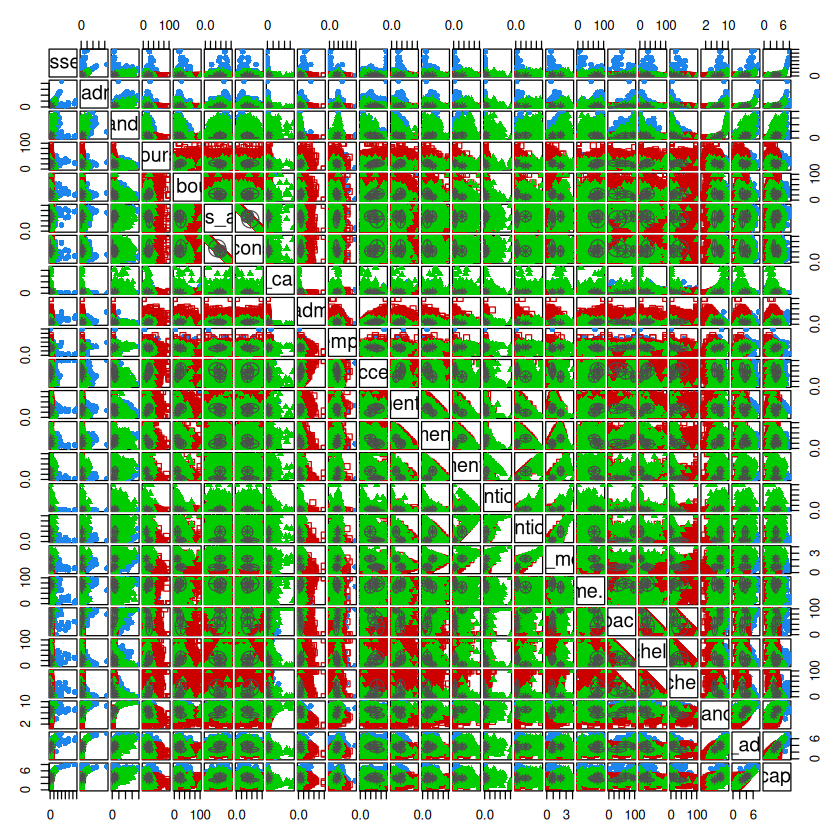

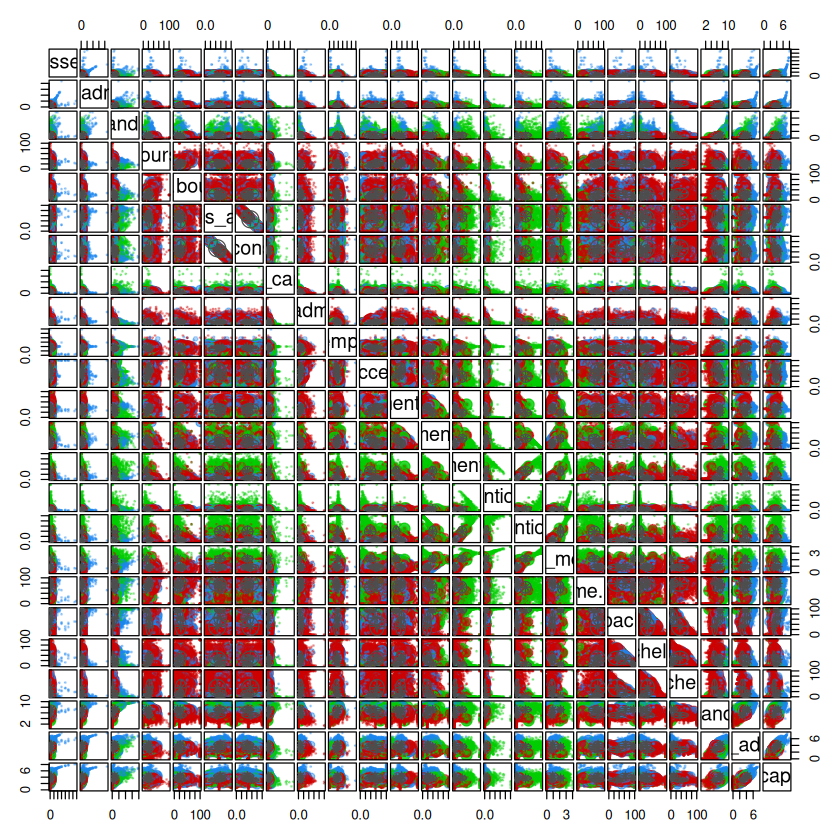

In [9]:
# Cluster assigné à chaque formation
df$cluster <- gmm_model$classification

# Probabilité d'appartenance (incertitude)
df$uncertainty <- gmm_model$uncertainty

# Visualiser
plot(gmm_model, what = "classification")
plot(gmm_model, what = "uncertainty")